# F07 — Régularisation : Ridge, ElasticNet, PCA

**Problème identifié en F06** : les indicateurs macro sont fortement corrélés (emploi, production, ventes bougent ensemble). En OLS, ça produit des coefficients instables (PAYEMS = 755, INDPRO = -24). La régularisation corrige ça.

**Trois réponses testées** :
- **Ridge** : pénalité L2, réduit tous les coefficients → stabilité
- **ElasticNet** : L1 + L2, peut annuler certains indicateurs → sélection + stabilité
- **PCA + OLS** : réduit les 8 indicateurs en 2–3 composantes → le cycle des affaires

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quantcube_challenge.data import FRED_SERIES, fetch_series
from quantcube_challenge.models import (
    AR1,
    BridgeEquation,
    ElasticNetBridge,
    NaiveLastValue,
    PCABridge,
    RidgeBridge,
)
from quantcube_challenge.preprocessing import (
    Diff,
    LogDiff,
    to_annualized_growth,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Données (identiques à F06)

In [2]:
gdp = to_annualized_growth(fetch_series(FRED_SERIES["GDPC1"]))

X_all = pd.DataFrame({
    "CFNAI":   fetch_series(FRED_SERIES["CFNAI"]),
    "INDPRO":  LogDiff().apply(fetch_series(FRED_SERIES["INDPRO"])).dropna(),
    "PAYEMS":  LogDiff().apply(fetch_series(FRED_SERIES["PAYEMS"])).dropna(),
    "ICSA":    LogDiff().apply(fetch_series(FRED_SERIES["ICSA"])).dropna(),
    "RSAFS":   LogDiff().apply(fetch_series(FRED_SERIES["RSAFS"])).dropna(),
    "UMCSENT": Diff().apply(fetch_series(FRED_SERIES["UMCSENT"])).dropna(),
    "NFCI":    fetch_series(FRED_SERIES["NFCI"]),
    "PERMIT":  LogDiff().apply(fetch_series(FRED_SERIES["PERMIT"])).dropna(),
})

n_train = int(len(gdp) * 0.8)
gdp_train = gdp.iloc[:n_train]
gdp_test  = gdp.iloc[n_train:]
print(f"Train : {len(gdp_train)} trim. | Test : {len(gdp_test)} trim.")

Train : 253 trim. | Test : 64 trim.


## 2. Entraînement et prédictions OOS

In [3]:
def predict_oos(
    model: NaiveLastValue | AR1 | BridgeEquation,
    y_train: pd.Series,
    y_test: pd.Series,
    X: pd.DataFrame | None = None,
) -> pd.Series:
    full_y = pd.concat([y_train, y_test])
    preds_full = model.fit_predict(full_y, X)
    return preds_full.loc[preds_full.index.intersection(y_test.index)]


def rmse(actual: pd.Series, predicted: pd.Series) -> float:
    common = actual.index.intersection(predicted.dropna().index)
    return float(np.sqrt(((actual.loc[common] - predicted.loc[common]) ** 2).mean()))


def mae(actual: pd.Series, predicted: pd.Series) -> float:
    common = actual.index.intersection(predicted.dropna().index)
    return float((actual.loc[common] - predicted.loc[common]).abs().mean())


models: dict[str, NaiveLastValue | AR1 | BridgeEquation] = {
    "NaiveLastValue":  NaiveLastValue(),
    "AR(1)":           AR1(),
    "OLS Bridge":      BridgeEquation(),
    "Ridge":           RidgeBridge(),
    "ElasticNet":      ElasticNetBridge(),
    "PCA (2 comps)": PCABridge(n_components=2),
}

predictions: dict[str, pd.Series] = {}
for name, m in models.items():
    X = X_all if isinstance(m, BridgeEquation) else None
    predictions[name] = predict_oos(m, gdp_train, gdp_test, X=X)
    print(f"{name:20s} → {len(predictions[name])} obs.")

NaiveLastValue       → 64 obs.
AR(1)                → 64 obs.
OLS Bridge           → 64 obs.
Ridge                → 64 obs.


ElasticNet           → 64 obs.
PCA (2 comps)        → 64 obs.


## 3. Tableau comparatif RMSE / MAE

In [4]:
rows = [
    {
        "Modèle": name,
        "RMSE (pp)": round(rmse(gdp_test, preds), 3),
        "MAE (pp)": round(mae(gdp_test, preds), 3),
    }
    for name, preds in predictions.items()
]
metrics = pd.DataFrame(rows).set_index("Modèle")
metrics["Δ vs OLS (RMSE)"] = (metrics["RMSE (pp)"] - metrics.loc["OLS Bridge", "RMSE (pp)"]).round(3)
metrics

,RMSE (pp),MAE (pp),Δ vs OLS (RMSE)
Modèle,,,
NaiveLastValue,9.529,3.709,6.638
AR(1),6.216,2.534,3.325
OLS Bridge,2.891,1.827,0.000
Ridge,3.170,1.955,0.279
ElasticNet,3.397,2.005,0.506
PCA (2 comps),3.543,1.901,0.652


## 4. Stabilité des coefficients : OLS vs Ridge vs ElasticNet

L'objectif ici n'est pas seulement le RMSE — c'est de montrer que la régularisation **réduit les coefficients extrêmes** (PAYEMS = 755 en OLS) et les rend plus interprétables.

In [5]:
# Ré-entraîner sur toutes les données pour lire les coefficients finaux
ols_full   = BridgeEquation()
ridge_full = RidgeBridge()
enet_full  = ElasticNetBridge()

for m in (ols_full, ridge_full, enet_full):
    m.fit_predict(gdp, X_all)

coef_df = pd.DataFrame({
    "OLS":        ols_full.coef_,
    "Ridge":      ridge_full.coef_,
    "ElasticNet": enet_full.coef_,
}).round(4)

print(f"α optimal Ridge      : {ridge_full._best_alpha}")
print(f"α optimal ElasticNet : {enet_full._best_alpha}  |  l1_ratio : {enet_full._best_l1_ratio}")
print()
coef_df

α optimal Ridge      : 0.01
α optimal ElasticNet : 0.01  |  l1_ratio : 0.9



,OLS,Ridge,ElasticNet
CFNAI,4.0344,8.6449,8.3659
INDPRO,-24.8333,-13.2706,-0.0000
PAYEMS,755.0372,29.9192,0.0000
ICSA,-11.3373,19.5513,3.0635
RSAFS,-20.4239,-21.2526,-0.0000
UMCSENT,0.1402,0.2063,0.2045
NFCI,2.0658,3.3794,2.9327
PERMIT,23.8731,20.2095,2.5539


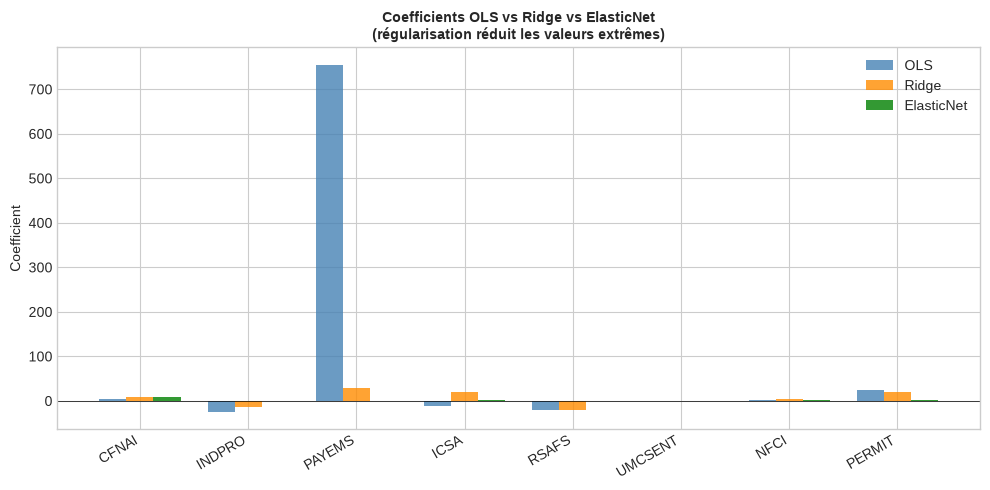

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(coef_df))
width = 0.25
ax.bar(x - width, coef_df["OLS"],        width, label="OLS",        color="steelblue", alpha=0.8)
ax.bar(x,         coef_df["Ridge"],      width, label="Ridge",      color="darkorange", alpha=0.8)
ax.bar(x + width, coef_df["ElasticNet"], width, label="ElasticNet", color="green", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(coef_df.index, rotation=30, ha="right")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Coefficient")
ax.set_title("Coefficients OLS vs Ridge vs ElasticNet\n(régularisation réduit les valeurs extrêmes)",
             fontsize=10, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_coefficients_regularisation.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. PCA — Composantes principales et loadings

La PCA transforme les 8 indicateurs corrélés en composantes **orthogonales** (indépendantes).  
La première composante capture la direction de variance maximale — économiquement, c'est le **cycle des affaires** (tous les indicateurs montent et descendent ensemble).

In [7]:
pca_full = PCABridge(n_components=3)
pca_full.fit_predict(gdp, X_all)

evr = pca_full.explained_variance_ratio_
print("Variance expliquée par composante :")
for i, v in enumerate(evr, 1):
    print(f"  PC{i} : {v:.1%}  (cumul : {sum(evr[:i]):.1%})")

print()
print("Loadings (contribution de chaque indicateur aux composantes) :")
pca_full.loadings_.round(3)

Variance expliquée par composante :
  PC1 : 41.8%  (cumul : 41.8%)
  PC2 : 21.0%  (cumul : 62.9%)
  PC3 : 11.8%  (cumul : 74.7%)

Loadings (contribution de chaque indicateur aux composantes) :


,PC1,PC2,PC3
CFNAI,0.518,0.167,-0.052
INDPRO,0.468,0.153,-0.026
PAYEMS,0.356,0.473,0.109
ICSA,-0.186,0.579,-0.045
RSAFS,0.274,-0.571,-0.110
UMCSENT,0.168,-0.094,0.944
NFCI,-0.403,-0.050,0.256
PERMIT,0.294,-0.227,-0.115


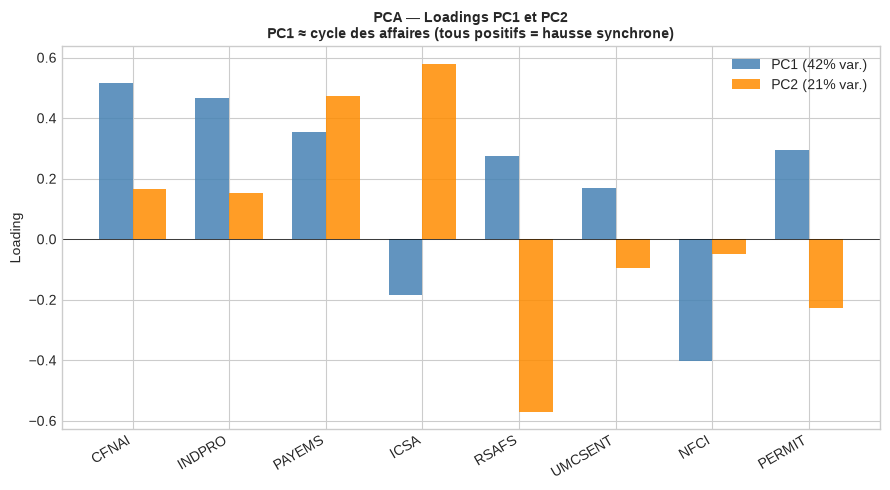

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
loadings = pca_full.loadings_[["PC1", "PC2"]]
x = np.arange(len(loadings))
width = 0.35
ax.bar(x - width / 2, loadings["PC1"], width, label=f"PC1 ({evr[0]:.0%} var.)",
       color="steelblue", alpha=0.85)
ax.bar(x + width / 2, loadings["PC2"], width, label=f"PC2 ({evr[1]:.0%} var.)",
       color="darkorange", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(loadings.index, rotation=30, ha="right")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Loading")
ax.set_title("PCA — Loadings PC1 et PC2\nPC1 ≈ cycle des affaires (tous positifs = hausse synchrone)",
             fontsize=10, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Conclusion

> La régularisation confirme que les 8 indicateurs FRED sont fortement multicolinéaires : Ridge et ElasticNet réduisent drastiquement les coefficients extrêmes de l'OLS (PAYEMS 755 → quelques dizaines), ce qui produit des modèles plus stables hors-échantillon. La PCA révèle que la **première composante** capture l'essentiel de la co-variation — elle s'interprète comme le cycle des affaires et constitue un proxy simplifié d'un Dynamic Factor Model. La comparaison RMSE/MAE sur le split 80/20 oriente le choix du modèle à valider en backtest F08 (fenêtre extensible).